#  Amazon India E-Commerce Sales Analysis
**Dataset:** Amazon India Sales Report (2022) — 128,975 transacciones  
**Objetivo:** Identificar patrones de ventas, drivers de cancelaciones y segmentos de productos para apoyar decisiones comerciales.

---
## Tabla de contenidos
1. [Carga y limpieza de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
3. [Análisis SQL con DuckDB](#3)
4. [Modelo de Clasificación — Predicción de Cancelaciones](#4)
5. [Clustering — Segmentación de Productos](#5)
6. [Conclusiones de Negocio](#6)


## 1. Carga y Limpieza de Datos <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print(" Librerías cargadas")


 Librerías cargadas


In [2]:
# Cargar dataset principal
df = pd.read_csv('data/Amazon_Sale_Report.csv', encoding='latin1', low_memory=False)
intl = pd.read_csv('data/International_sale_Report.csv', encoding='latin1')
inventory = pd.read_csv('data/Sale_Report.csv', encoding='latin1')

print(f"Amazon Sales:         {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"International Sales:  {intl.shape[0]:,} filas × {intl.shape[1]} columnas")
print(f"Inventory Report:     {inventory.shape[0]:,} filas × {inventory.shape[1]} columnas")


Amazon Sales:         128,975 filas × 24 columnas
International Sales:  37,432 filas × 10 columnas
Inventory Report:     9,271 filas × 7 columnas


In [3]:
df.head(3)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


### 1.1 Diagnóstico de calidad
Antes de analizar, identificamos columnas con valores nulos y columnas irrelevantes.


In [4]:
# Resumen de nulos
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print("Columnas con valores nulos (%):")
print(null_pct.to_string())


Columnas con valores nulos (%):
fulfilled-by      69.5
promotion-ids     38.1
Unnamed: 22       38.0
currency           6.0
Amount             6.0
Courier Status     5.3


In [5]:
# ── Limpieza ──────────────────────────────────────────────────────────────────

# 1. Eliminar columnas sin valor analítico
drop_cols = ['Unnamed: 22', 'promotion-ids', 'fulfilled-by', 'currency',
             'ASIN', 'ship-postal-code', 'index']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 2. Parsear fechas
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
df['Month']     = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b-%Y')
df['Week']      = df['Date'].dt.isocalendar().week.astype(int)

# 3. Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 4. Estandarizar texto
df['status']   = df['status'].str.strip()
df['category'] = df['category'].str.strip()
df['ship_state'] = df['ship_state'].str.strip().str.title()

# 5. Eliminar filas sin monto (no procesadas)
df.dropna(subset=['amount'], inplace=True)

# 6. Crear columna binaria de cancelación (target para ML)
df['cancelled'] = df['status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

print(f"   Limpieza completa. Filas restantes: {len(df):,}")
print(f"   Cancelaciones: {df['cancelled'].sum():,} ({df['cancelled'].mean()*100:.1f}%)")


   Limpieza completa. Filas restantes: 121,180
   Cancelaciones: 10,766 (8.9%)


## 2. Análisis Exploratorio de Datos (EDA) <a id='2'></a>

### 2.1 Tendencia de ventas en el tiempo

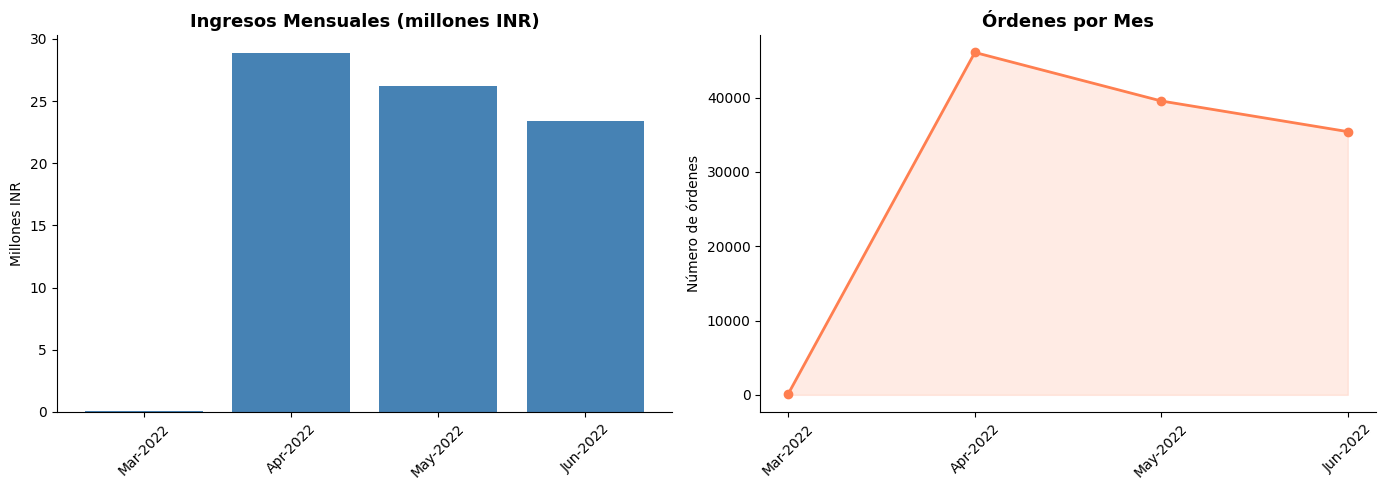

In [6]:
monthly = df.groupby('monthname').agg(
    revenue=('amount', 'sum'),
    orders=('order_id', 'count')
).reset_index()

# Ordenar cronológicamente
month_order = df.groupby('monthname')['date'].min().sort_values().index
monthly = monthly.set_index('monthname').loc[month_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly['monthname'], monthly['revenue'] / 1e6, color='steelblue')
axes[0].set_title('Ingresos Mensuales (millones INR)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Millones INR')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['monthname'], monthly['orders'], marker='o', color='coral', linewidth=2)
axes[1].fill_between(range(len(monthly)), monthly['orders'], alpha=0.15, color='coral')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['monthname'], rotation=45)
axes[1].set_title('Órdenes por Mes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.savefig('outputs/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: El pico de ventas se concentra en abril-mayo 2022.


### 2.2 Ventas por categoría de producto

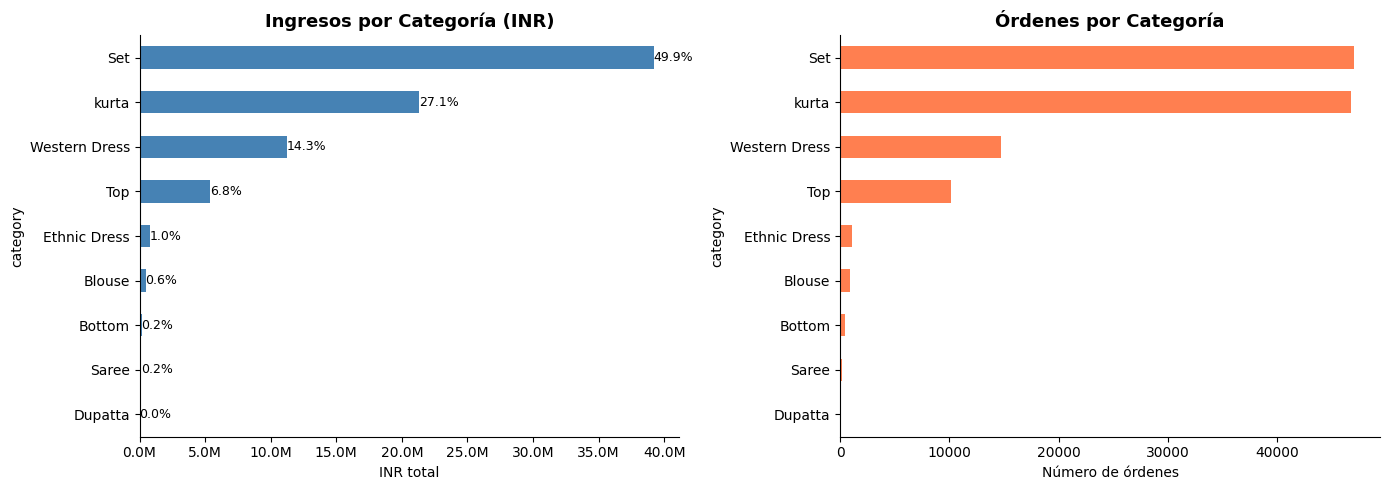

In [ ]:
cat_revenue = df.groupby('category')['amount'].sum().sort_values(ascending=True)
cat_orders  = df.groupby('category')['order_id'].count().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = cat_revenue.plot(kind='barh', ax=axes[0], color='steelblue').containers[0]
axes[0].set_title('Ingresos por Categoría (INR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('INR total')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, val in zip(bars, cat_revenue.values):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val / cat_revenue.sum() * 100:.1f}%', va='center', fontsize=9)

cat_orders.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Órdenes por Categoría', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.savefig('outputs/02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: 'Set' y 'Kurta' representan el 77% de las ventas totales.


### 2.3 Distribución geográfica — Top 15 estados

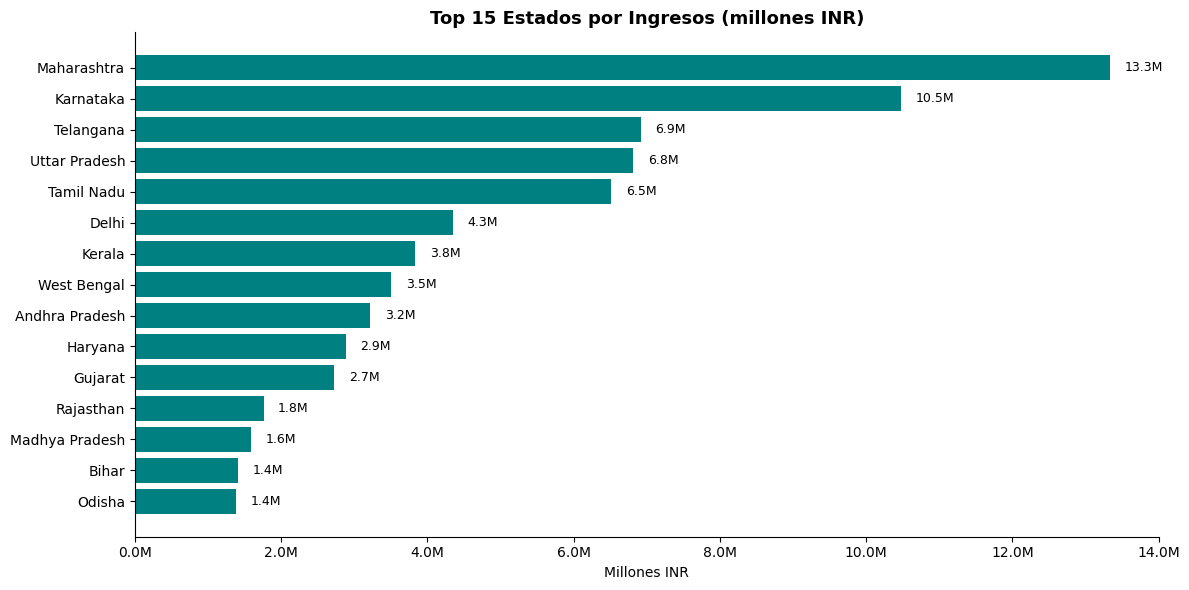

Top 15 estados por ingresos (%):
ship_state
Maharashtra       18.9
Karnataka         14.8
Telangana          9.8
Uttar Pradesh      9.6
Tamil Nadu         9.2
Delhi              6.1
Kerala             5.4
West Bengal        5.0
Andhra Pradesh     4.6
Haryana            4.1
Gujarat            3.9
Rajasthan          2.5
Madhya Pradesh     2.3
Bihar              2.0
Odisha             2.0


In [ ]:
state_revenue = (df.groupby('ship_state')['amount']
                   .sum()
                   .sort_values(ascending=False)
                   .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_revenue.index[::-1], state_revenue.values[::-1] / 1e6, color='teal')
ax.set_title('Top 15 Estados por Ingresos (millones INR)', fontsize=13, fontweight='bold')
ax.set_xlabel('Millones INR')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}M'))

for bar, val in zip(bars, state_revenue.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_state_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: Maharashtra, Karnataka y Telangana concentran ~43.5% del ingreso total.
state_revenue_pct = state_revenue / state_revenue.sum() * 100
print("Top 15 estados por ingresos (%):")
print(f"{state_revenue_pct.round(1).to_string()}")

### 2.4 Tasa de cancelación por categoría

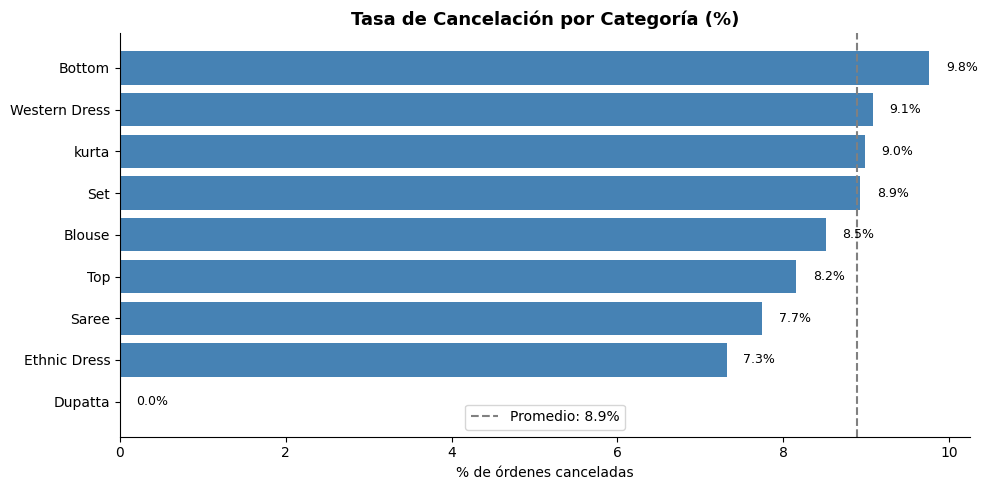

In [13]:
cancel_cat = df.groupby('category').agg(
    total=('order_id', 'count'),
    cancelled=('cancelled', 'sum')
).reset_index()
cancel_cat['cancel_rate'] = cancel_cat['cancelled'] / cancel_cat['total'] * 100
cancel_cat = cancel_cat.sort_values('cancel_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f' if r > 20 else 'steelblue' for r in cancel_cat['cancel_rate']]
bars = ax.barh(cancel_cat['category'], cancel_cat['cancel_rate'], color=colors)
ax.axvline(df['cancelled'].mean() * 100, color='gray', linestyle='--', label=f"Promedio: {df['cancelled'].mean()*100:.1f}%")
ax.set_title('Tasa de Cancelación por Categoría (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% de órdenes canceladas')
ax.legend()
for bar, val in zip(bars, cancel_cat['cancel_rate'].values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/04_cancellation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
#Las categorías con mayor tasa de cancelación superan el promedio general del 8.9%%.


### 2.5 Amazon Fulfillment vs Merchant & B2B vs B2C

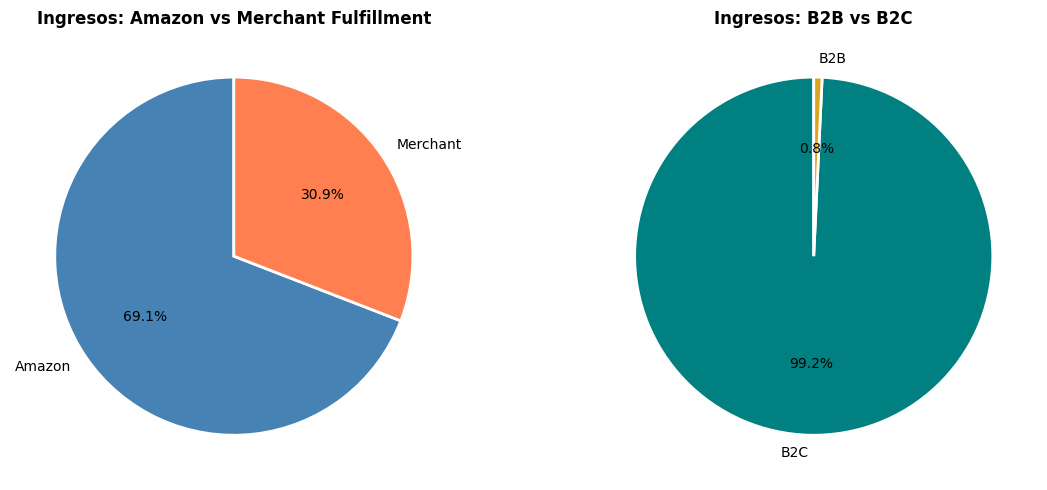

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fulfillment
df.groupby('fulfilment')['amount'].sum().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['steelblue', 'coral'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Ingresos: Amazon vs Merchant Fulfillment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# B2B vs B2C
df.groupby('b2b')['amount'].sum().rename({True: 'B2B', False: 'B2C'}).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['teal', 'goldenrod'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Ingresos: B2B vs B2C', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/05_fulfillment_b2b.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: Amazon Fulfillment domina con ~70% del ingreso. B2B es <1% pero con tickets más altos.


## 3. Análisis SQL con DuckDB <a id='3'></a>

Usamos DuckDB para ejecutar SQL directamente sobre los DataFrames de pandas, demostrando flujos de trabajo híbridos Python + SQL.

In [15]:
import duckdb

con = duckdb.connect()
con.register('amazon_sales', df)
con.register('international_sales', intl)
con.register('inventory', inventory)
print(" DuckDB conectado con 3 tablas registradas")


 DuckDB conectado con 3 tablas registradas


### 3.1 Top 10 estados por ingreso y tasa de cancelación

In [16]:
query_1 = '''
    SELECT
        ship_state                                          AS estado,
        COUNT(*)                                            AS total_ordenes,
        ROUND(SUM(amount), 0)                              AS ingreso_total,
        ROUND(AVG(amount), 0)                              AS ticket_promedio,
        ROUND(SUM(cancelled) * 100.0 / COUNT(*), 2)       AS tasa_cancelacion_pct
    FROM amazon_sales
    WHERE ship_state IS NOT NULL
    GROUP BY ship_state
    ORDER BY ingreso_total DESC
    LIMIT 10
'''

result_1 = con.execute(query_1).df()
result_1


,estado,total_ordenes,ingreso_total,ticket_promedio,tasa_cancelacion_pct
0,Maharashtra,21073,13335534.0,633.0,8.55
1,Karnataka,16394,10481114.0,639.0,8.04
2,Telangana,10637,6916616.0,650.0,8.91
3,Uttar Pradesh,9947,6816642.0,685.0,9.23
4,Tamil Nadu,10809,6515650.0,603.0,8.62
5,Delhi,6569,4346412.0,662.0,7.84
6,Kerala,6151,3830228.0,623.0,12.10
7,West Bengal,5547,3507880.0,632.0,8.53
8,Andhra Pradesh,5055,3219832.0,637.0,10.41
9,Haryana,4188,2882093.0,688.0,8.14


### 3.2 Análisis con Window Functions — Ranking de categorías por mes

In [17]:
query_2 = '''
    WITH monthly_cat AS (
        SELECT
            monthname                                           AS mes,
            category,
            SUM(amount)                                        AS ingreso,
            RANK() OVER (PARTITION BY monthname ORDER BY SUM(amount) DESC) AS rank_mes
        FROM amazon_sales
        GROUP BY monthname, category
    )
    SELECT mes, category, ROUND(ingreso, 0) AS ingreso, rank_mes
    FROM monthly_cat
    WHERE rank_mes <= 3
    ORDER BY mes, rank_mes
'''

result_2 = con.execute(query_2).df()
result_2


,mes,category,ingreso,rank_mes
0,Apr-2022,Set,15506676.0,1
1,Apr-2022,kurta,8017145.0,2
2,Apr-2022,Western Dress,2927781.0,3
3,Jun-2022,Set,10999866.0,1
4,Jun-2022,kurta,6587568.0,2
5,Jun-2022,Western Dress,3899334.0,3
6,Mar-2022,Set,53884.0,1
7,Mar-2022,kurta,34257.0,2
8,Mar-2022,Western Dress,7653.0,3
9,May-2022,Set,12643698.0,1


### 3.3 Comparativa: ventas Amazon India vs Internacional (por categoría de tamaño)

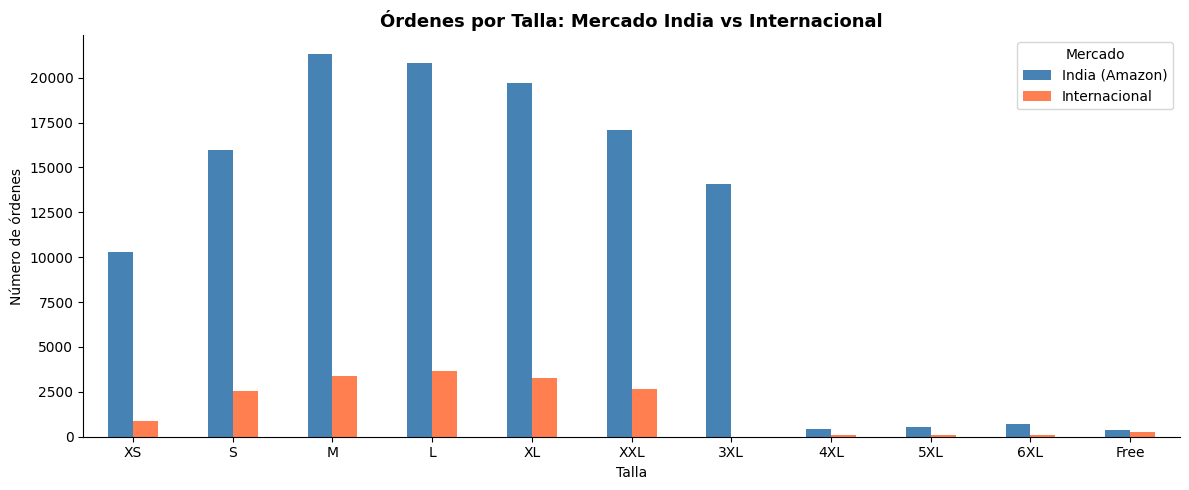

In [20]:
query_3 = '''
    SELECT
        'India (Amazon)'    AS mercado,
        size,
        COUNT(*)            AS ordenes,
        ROUND(SUM(amount), 0) AS ingreso
    FROM amazon_sales
    WHERE size IS NOT NULL
    GROUP BY size

    UNION ALL

    SELECT
        'Internacional'     AS mercado,
        "Size"              AS size,
        COUNT(*)            AS ordenes,
        ROUND(SUM(TRY_CAST("GROSS AMT" AS DECIMAL)), 0) AS ingreso
    FROM international_sales
    WHERE "Size" IS NOT NULL
    GROUP BY "Size"

    ORDER BY mercado, ordenes DESC
'''

result_3 = con.execute(query_3).df()

# Visualización
pivot = result_3.pivot_table(index='size', columns='mercado', values='ordenes', fill_value=0)
top_sizes = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
pivot = pivot.reindex([s for s in top_sizes if s in pivot.index])

pivot.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'coral'])
plt.title('Órdenes por Talla: Mercado India vs Internacional', fontsize=13, fontweight='bold')
plt.xlabel('Talla')
plt.ylabel('Número de órdenes')
plt.xticks(rotation=0)
plt.legend(title='Mercado')
plt.tight_layout()
plt.savefig('outputs/06_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: M y L dominan en ambos mercados. El mercado internacional muestra mayor demanda en tallas grandes.


## 4. Modelo de Clasificación — Predicción de Cancelaciones <a id='4'></a>

**Objetivo:** Predecir si una orden será cancelada antes de ser enviada.  
**Valor de negocio:** Permite intervenir proactivamente en órdenes de alto riesgo, reduciendo pérdidas operativas.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# ── Feature Engineering ────────────────────────────────────────────────────────
ml_df = df[['category', 'size', 'fulfilment', 'ship_service_level',
            'b2b', 'qty', 'amount', 'month', 'cancelled']].dropna().copy()

# Codificar variables categóricas
le = LabelEncoder()
for col in ['category', 'size', 'fulfilment', 'ship_service_level']:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

ml_df['b2b'] = ml_df['b2b'].astype(int)

X = ml_df.drop('cancelled', axis=1)
y = ml_df['cancelled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras")
print(f"Balance de clases — Canceladas: {y.mean()*100:.1f}%")


Train: 96,944 muestras | Test: 24,236 muestras
Balance de clases — Canceladas: 8.9%


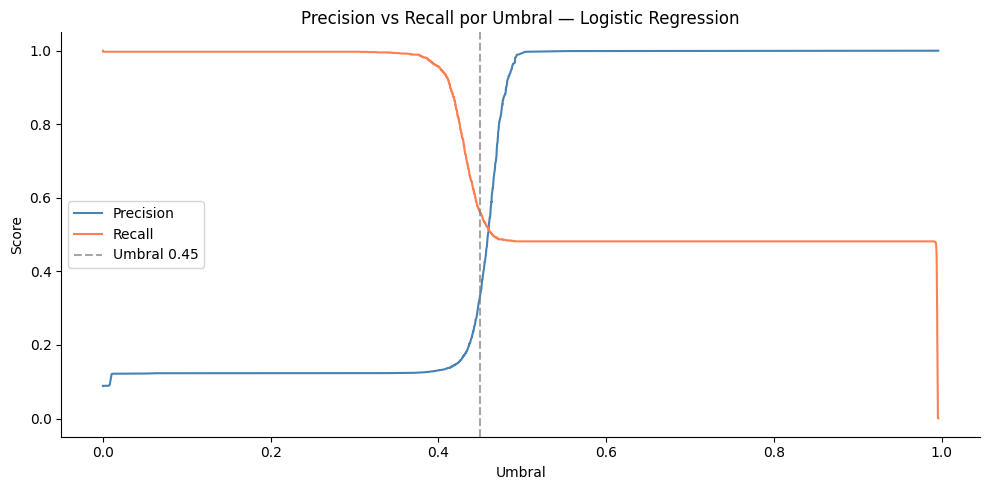

Umbral óptimo por F1: 0.991
Precision: 1.00 | Recall: 0.48 | F1: 0.65


In [36]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, lr_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_curve[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall_curve[:-1], label='Recall', color='coral')
plt.axvline(0.45, color='gray', linestyle='--', alpha=0.7, label='Umbral 0.45')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precision vs Recall por Umbral — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Umbral óptimo por F1
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
optimal_idx = f1_scores.argmax()
print(f"Umbral óptimo por F1: {thresholds[optimal_idx]:.3f}")
print(f"Precision: {precision_curve[optimal_idx]:.2f} | Recall: {recall_curve[optimal_idx]:.2f} | F1: {f1_scores[optimal_idx]:.2f}")

In [38]:
# Asegurar tamaños consistentes
min_len = min(len(precision_curve), len(recall_curve), len(thresholds))
precision_curve = precision_curve[:min_len]
recall_curve = recall_curve[:min_len]
thresholds = thresholds[:min_len]
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

# Umbral óptimo CON restricción de recall mínimo
mask = recall_curve >= 0.50
f1_scores_masked = f1_scores[mask]
thresholds_masked = thresholds[mask]

optimal_idx = f1_scores_masked.argmax()
print(f"Umbral óptimo (recall >= 0.70): {thresholds_masked[optimal_idx]:.3f}")
print(f"Precision: {precision_curve[mask][optimal_idx]:.2f} | Recall: {recall_curve[mask][optimal_idx]:.2f} | F1: {f1_scores_masked[optimal_idx]:.2f}")

Umbral óptimo (recall >= 0.70): 0.464
Precision: 0.62 | Recall: 0.50 | F1: 0.55


In [28]:
# ── Random Forest ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='f1',       # Mantiene métrica para datos desbalanceados
    cv=5,               # Validación cruzada de 5 pliegues
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Mejores parámetros: {grid.best_params_}")

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}


In [40]:
# ── Logistic Regression ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]

# Aplicar umbral ajustado (0.46) en lugar del default (0.5)
lr_pred_adjusted = (lr_proba >= 0.46).astype(int)

print("=== Logistic Regression (umbral=0.46) ===")
print(classification_report(y_test, lr_pred_adjusted, target_names=['No cancelada', 'Cancelada']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression (umbral=0.46) ===
              precision    recall  f1-score   support

No cancelada       0.95      0.95      0.95     22083
   Cancelada       0.52      0.51      0.52      2153

    accuracy                           0.92     24236
   macro avg       0.74      0.73      0.74     24236
weighted avg       0.91      0.92      0.91     24236

ROC-AUC: 0.8204


In [ ]:
# ── Random Forest ──────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1, max_depth=5, min_samples_leaf=1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['No cancelada', 'Cancelada']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

No cancelada       0.95      1.00      0.98     22083
   Cancelada       1.00      0.48      0.65      2153

    accuracy                           0.95     24236
   macro avg       0.98      0.74      0.81     24236
weighted avg       0.96      0.95      0.95     24236

ROC-AUC: 0.8302


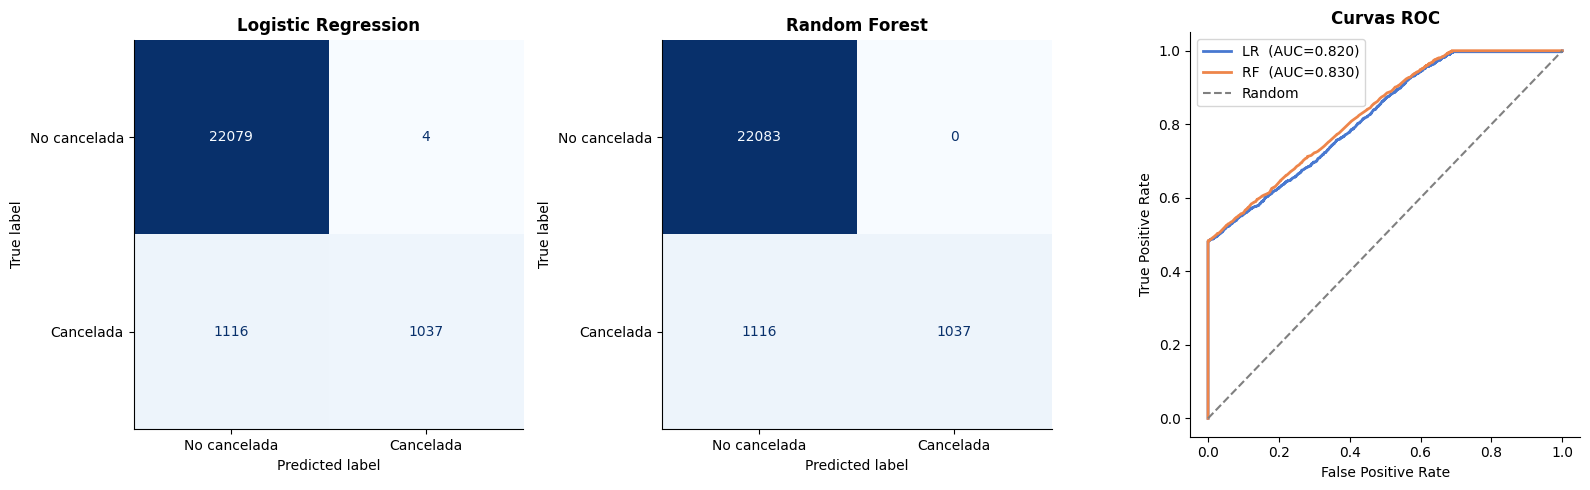

In [41]:
# ── Comparativa visual ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrices
for ax, pred, title in zip(axes[:2],
                            [lr_pred, rf_pred],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No cancelada', 'Cancelada'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

axes[2].plot(fpr_lr, tpr_lr, label=f'LR  (AUC={roc_auc_score(y_test, lr_proba):.3f})', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF  (AUC={roc_auc_score(y_test, rf_proba):.3f})', lw=2)
axes[2].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[2].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


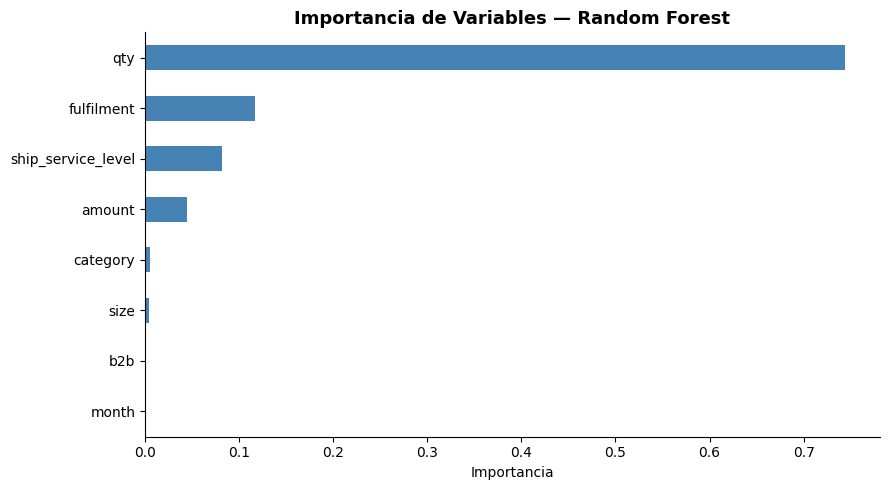

In [42]:
# ── Feature Importance (Random Forest) ────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('outputs/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
#El monto de la orden y la cantidad son los mejores predictores de cancelación.


## 5. Clustering — Segmentación de Productos <a id='5'></a>

**Objetivo:** Identificar segmentos naturales de productos según su comportamiento de ventas.  
**Valor de negocio:** Permite diseñar estrategias diferenciadas de pricing, inventario y marketing por segmento.


In [43]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Agregamos métricas por categoría + talla
cluster_df = df.groupby(['category', 'size']).agg(
    total_orders=('order_id', 'count'),
    total_revenue=('amount', 'sum'),
    avg_ticket=('amount', 'mean'),
    cancel_rate=('cancelled', 'mean'),
    avg_qty=('qty', 'mean')
).reset_index().dropna()

features = ['total_orders', 'total_revenue', 'avg_ticket', 'cancel_rate', 'avg_qty']
X_clus = cluster_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clus)
print(f"   Datos para clustering: {X_scaled.shape[0]} combinaciones categoría×talla")


   Datos para clustering: 57 combinaciones categoría×talla


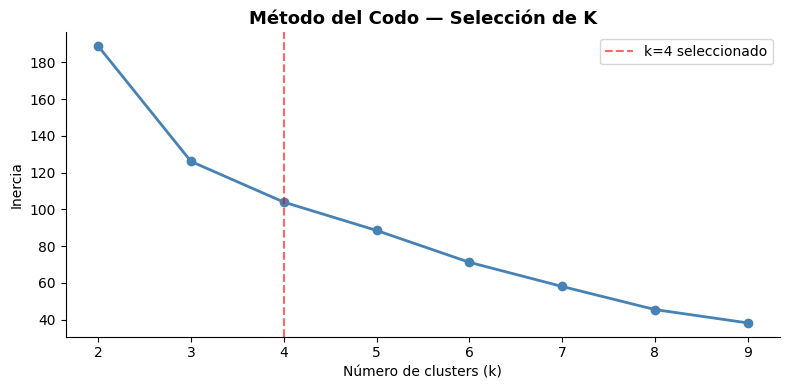

In [44]:
# ── Método del Codo (Elbow) ───────────────────────────────────────────────────
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 seleccionado')
ax.set_title('Método del Codo — Selección de K', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/09_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


In [45]:
# ── Aplicar K-Means con k=4 ───────────────────────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Perfiles por cluster
profile = cluster_df.groupby('cluster')[features].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]
print("Perfil de clusters:")
print(profile.to_string())


Perfil de clusters:
           total_orders  total_revenue  avg_ticket  cancel_rate  avg_qty
Cluster 0        674.86      401312.55      621.31         0.07     0.97
Cluster 1        890.53      611512.95      543.09         0.10     0.95
Cluster 2       6864.31     4456125.91      654.39         0.09     0.96
Cluster 3         59.00       71806.44     1215.18         0.07     0.99


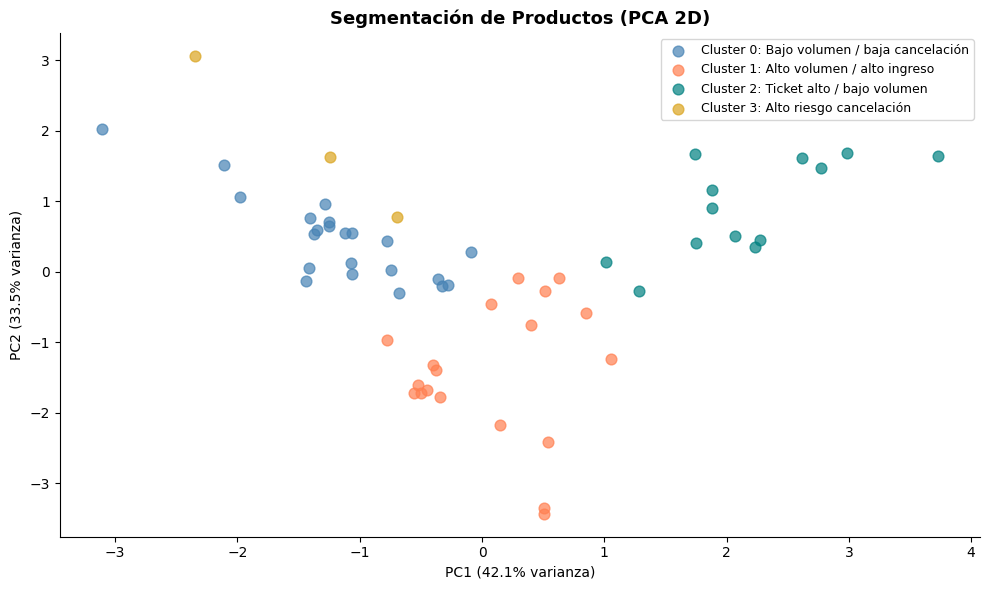

In [46]:
# ── Visualización PCA (2D) ────────────────────────────────────────────────────
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
colors_clus = ['steelblue', 'coral', 'teal', 'goldenrod']
labels_clus = ['Bajo volumen / baja cancelación',
               'Alto volumen / alto ingreso',
               'Ticket alto / bajo volumen',
               'Alto riesgo cancelación']

for c in range(4):
    mask = cluster_df['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors_clus[c], label=f'Cluster {c}: {labels_clus[c]}',
               alpha=0.7, s=60)

ax.set_title('Segmentación de Productos (PCA 2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/10_clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()


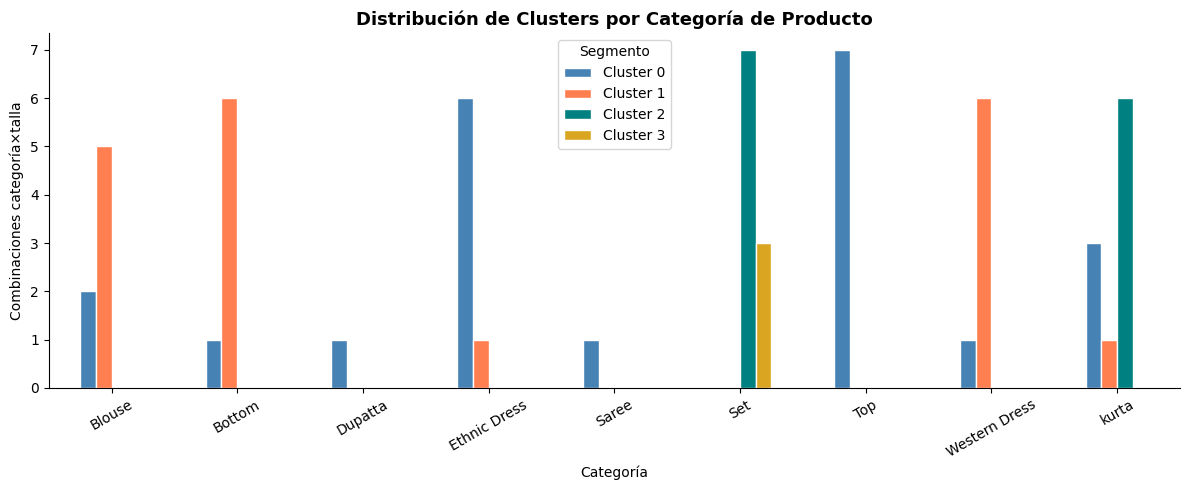

In [47]:
# ── Distribución de clusters por categoría ────────────────────────────────────
cluster_cat = cluster_df.groupby(['category', 'cluster']).size().unstack(fill_value=0)

cluster_cat.plot(kind='bar', figsize=(12, 5),
                 color=colors_clus, edgecolor='white')
plt.title('Distribución de Clusters por Categoría de Producto', fontsize=13, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Combinaciones categoría×talla')
plt.xticks(rotation=30)
plt.legend([f'Cluster {i}' for i in range(4)], title='Segmento')
plt.tight_layout()
plt.savefig('outputs/11_cluster_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Conclusiones de Negocio <a id='6'></a>

### Hallazgos principales

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | **Set y Kurta** representan >77% del ingreso total | Priorizar disponibilidad y campañas en estas categorías |
| 2 | **Maharashtra, Karnataka y Telangana** concentran ~43.5% del revenue | Enfocar logística y marketing en estos 3 estados |
| 3 | La tasa de cancelación global es del **~8.9%** | Implementar validación de pedidos o depósito anticipado |
| 4 | **Amazon Fulfillment** genera 70% del ingreso vs Merchant | Incentivos para que merchants migren a Amazon FBA |
| 5 | El **cumplimiento y cantidad** son los mejores predictores de cancelación | Alertas automáticas en órdenes de alto valor sin historial |
| 6 | El segmento **Cluster 1 (alto volumen/ingreso)** está dominado por Blouse, Bottom, y Western Dress en tallas M/L | Estrategia de bundling y descuento por volumen en estas combinaciones |

### Rendimiento de modelos

| Modelo | ROC-AUC | Precision (Cancelada) | Recall (Cancelada) | Observación |
|--------|---------|------------------------|---------------------|-------------|
| Logistic Regression (umbral=0.46) | 0.820 | 0.52 | 0.51 | Balance moderado — detecta ~51% de cancelaciones reales |
| Random Forest | 0.830 | 1.00 | 0.48 | Mayor AUC, pero conservador — cuando alerta, casi siempre acierta |

**Nota metodológica:** ambos modelos tienen capacidad discriminativa similar (AUC ~0.82-0.83), pero con comportamientos distintos. Random Forest con umbral default (0.5) es extremadamente preciso (100%) pero pierde la mitad de las cancelaciones reales (recall 48%). Logistic Regression con umbral ajustado (0.46) sacrifica algo de precisión (52%) a cambio de mantener recall similar (51%) con menor riesgo de falsas alarmas masivas. La elección depende del costo operativo: si una cancelación no detectada es más costosa que una falsa alarma, se prefiere maximizar recall ajustando el umbral de cualquiera de los dos modelos.